In [12]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/selmakh/siglip/siglip/reward_shaping.py
/kaggle/input/datasets/selmakh/siglip/siglip/gamma_train.py
/kaggle/input/datasets/selmakh/siglip/siglip/embeddings_gamma_768.npy
/kaggle/input/datasets/selmakh/siglip/siglip/environment.py
/kaggle/input/datasets/selmakh/siglip/siglip/gamma_pipeline.py
/kaggle/input/datasets/selmakh/siglip/siglip/gamma_feature_extractor.py
/kaggle/input/datasets/selmakh/siglip/siglip/config.py
/kaggle/input/datasets/selmakh/siglip/siglip/environment_ikram.py
/kaggle/input/datasets/selmakh/siglip/siglip/gamma_env_wrapper.py
/kaggle/input/datasets/selmakh/siglip/siglip/nlp_instructions.csv


In [13]:
!pip install pybullet stable-baselines3 gymnasium transformers sentencepiece torch -q

In [14]:
import sys, os, shutil

os.makedirs('/kaggle/working/robotics/env/src', exist_ok=True)
os.makedirs('/kaggle/working/rl', exist_ok=True)
os.makedirs('/kaggle/working/nlp', exist_ok=True)

base = '/kaggle/input/datasets/selmakh/siglip/siglip/'  # your actual dataset path

shutil.copy(base + 'gamma_env_wrapper.py',      '/kaggle/working/rl/')
shutil.copy(base + 'gamma_feature_extractor.py', '/kaggle/working/rl/')
shutil.copy(base + 'reward_shaping.py',          '/kaggle/working/rl/')
shutil.copy(base + 'gamma_pipeline.py',          '/kaggle/working/nlp/')
shutil.copy(base + 'embeddings_gamma_768.npy',   '/kaggle/working/nlp/')
shutil.copy(base + 'nlp_instructions.csv',       '/kaggle/working/nlp/')

for folder in ['/kaggle/working/robotics', '/kaggle/working/robotics/env',
               '/kaggle/working/robotics/env/src', '/kaggle/working/rl',
               '/kaggle/working/nlp']:
    open(folder + '/__init__.py', 'w').close()

sys.path.insert(0, '/kaggle/working')
sys.path.insert(0, '/kaggle/working/robotics')
print("Paths ready")

Paths ready


In [15]:
gamma_train = '''
import os
import sys
import torch

# Must be set before any transformers import — applies in this process only
# (DummyVecEnv runs in same process so this is enough)
os.environ["TRANSFORMERS_OFFLINE"] = "1"
os.environ["HF_DATASETS_OFFLINE"] = "1"

from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import CheckpointCallback, EvalCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv

sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), "..")))

from rl.gamma_feature_extractor import GammaFeatureExtractor
from rl.gamma_env_wrapper import GammaLanguageConditionedWrapper
from rl.reward_shaping import RewardShapingWrapper
from robotics.env.src.environment import KukaEnv

NUM_ENVS        = 4
TOTAL_TIMESTEPS = 300_000
N_STEPS         = 512
FEATURES_DIM    = 256
LEARNING_RATE   = 3e-4
ENT_COEF        = 0.02
CLIP_RANGE      = 0.2
N_EPOCHS        = 5
CHECKPOINT_FREQ = 10_000
RESUME_PATH     = None


def make_env():
    def _init():
        raw     = KukaEnv(render_mode="rgb_array")
        wrapped = GammaLanguageConditionedWrapper(raw)
        shaped  = RewardShapingWrapper(wrapped)
        return Monitor(shaped)
    return _init


def main():
    print("CUDA available: {}".format(torch.cuda.is_available()))
    print("Device count:   {}".format(torch.cuda.device_count()))

    # DummyVecEnv: all envs in same process — single SigLIP load, no subprocess issues
    # SigLIP inference is the bottleneck so SubprocVecEnv gives no real speedup anyway
    print("Loading {} train envs sequentially...".format(NUM_ENVS))
    env = DummyVecEnv([make_env() for _ in range(NUM_ENVS)])
    print("Train envs ready.")

    policy_kwargs = dict(
        features_extractor_class=GammaFeatureExtractor,
        features_extractor_kwargs=dict(features_dim=FEATURES_DIM),
    )

    log_dir = "./logs/gamma/"
    os.makedirs(log_dir, exist_ok=True)
    os.makedirs("./checkpoints/gamma/best/", exist_ok=True)

    if RESUME_PATH and os.path.exists(RESUME_PATH + ".zip"):
        print("Resuming from {}".format(RESUME_PATH))
        model = PPO.load(RESUME_PATH, env=env, tensorboard_log=log_dir)
        model.ent_coef   = ENT_COEF
        model.clip_range = CLIP_RANGE
    else:
        model = PPO(
            "MultiInputPolicy",
            env,
            policy_kwargs=policy_kwargs,
            verbose=1,
            tensorboard_log=log_dir,
            learning_rate=LEARNING_RATE,
            n_steps=N_STEPS,
            batch_size=64,
            ent_coef=ENT_COEF,
            clip_range=CLIP_RANGE,
            n_epochs=N_EPOCHS,
            device="cuda",
        )

    checkpoint_cb = CheckpointCallback(
        save_freq=CHECKPOINT_FREQ // NUM_ENVS,
        save_path="./checkpoints/gamma/",
        name_prefix="gamma_ppo",
        save_replay_buffer=False,
        save_vecnormalize=False,
    )

    # DummyVecEnv for eval too — matches train env type, no mismatch warning
    print("Loading eval env...")
    eval_env = DummyVecEnv([make_env()])
    print("Eval env ready.")

    eval_cb = EvalCallback(
        eval_env,
        best_model_save_path="./checkpoints/gamma/best/",
        log_path=log_dir,
        eval_freq=max(10_000 // NUM_ENVS, 1),
        n_eval_episodes=5,
        deterministic=True,
        verbose=1,
    )

    samples_per_update = NUM_ENVS * N_STEPS
    print(
        "Gamma training — {} envs x {} steps = {:,} samples/update | "
        "{:,} total steps = {} updates | "
        "TensorBoard: tensorboard --logdir={}".format(
            NUM_ENVS, N_STEPS, samples_per_update,
            TOTAL_TIMESTEPS, TOTAL_TIMESTEPS // samples_per_update, log_dir
        )
    )

    try:
        model.learn(
            total_timesteps=TOTAL_TIMESTEPS,
            callback=[checkpoint_cb, eval_cb],
            reset_num_timesteps=RESUME_PATH is None,
        )
        model.save("checkpoints/gamma/final_gamma_ppo")
        print("Done — checkpoints/gamma/final_gamma_ppo.zip")
    except KeyboardInterrupt:
        model.save("checkpoints/gamma/interrupted_gamma_ppo")
        print("Interrupted — checkpoint saved.")


if __name__ == "__main__":
    main()
'''

with open('/kaggle/working/rl/gamma_train.py', 'w') as f:
    f.write(gamma_train)
print("gamma_train.py written")

gamma_train.py written


In [16]:
config_code = '''
from enum import Enum
import pybullet as p
import numpy as np

class GraphicalMode(Enum):
    GUI = p.GUI
    DIRECT = p.DIRECT

class RenderMode(Enum):
    HUMAN = "human"
    RGB_ARRAY = "rgb_array"

NUM_JOINTS = 7
END_EFFECTOR_LINK_INDEX = 6
MAX_FORCE = 300.0
SIM_TIMESTEP = 1.0 / 240.0
SIM_STEPS_PER_ACTION = 4
MAX_EPISODE_STEPS = 500

JOINT_LOWER_LIMITS = np.array([-2.9671, -2.0944, -2.9671, -2.0944, -2.9671, -2.0944, -3.0543], dtype=np.float32)
JOINT_UPPER_LIMITS = np.array([2.9671, 2.0944, 2.9671, 2.0944, 2.9671, 2.0944, 3.0543], dtype=np.float32)
HOME_POSITION = np.zeros(7, dtype=np.float32)
MAX_JOINT_VELOCITY = 10.0

WORKSPACE_LOW  = np.array([-1.5, -1.5, 0.0], dtype=np.float32)
WORKSPACE_HIGH = np.array([1.5,  1.5,  1.5], dtype=np.float32)

CAM_DISTANCE = 1.5
CAM_YAW = 50
CAM_PITCH = -35
CAM_TARGET = [0, 0, 0.5]
RENDER_FPS = 30
RENDER_WIDTH = 224
RENDER_HEIGHT = 224

NUM_OBJECTS = 4
OBJECT_COLORS = {
    "red":    [1.0, 0.0, 0.0, 1.0],
    "green":  [0.0, 1.0, 0.0, 1.0],
    "blue":   [0.0, 0.0, 1.0, 1.0],
    "yellow": [1.0, 1.0, 0.0, 1.0],
}
OBJECT_SHAPES = ["box", "sphere", "cylinder"]
OBJECT_SIZE_MIN = 0.02
OBJECT_SIZE_MAX = 0.05
TABLE_POSITION     = [0.5, 0.0, 0.2]
TABLE_HALF_EXTENTS = [0.4, 0.4, 0.05]
TABLE_SURFACE_Z    = 0.42
SPAWN_RANGE        = 0.22
'''

with open('/kaggle/working/robotics/env/src/config.py', 'w') as f:
    f.write(config_code)
print("config.py written")

config.py written


In [17]:
environment_code = '''
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pybullet as p
import pybullet_data

from env.src.config import GraphicalMode, NUM_JOINTS, END_EFFECTOR_LINK_INDEX, MAX_FORCE, SIM_TIMESTEP, SIM_STEPS_PER_ACTION, MAX_EPISODE_STEPS, JOINT_LOWER_LIMITS, JOINT_UPPER_LIMITS, HOME_POSITION, MAX_JOINT_VELOCITY, WORKSPACE_LOW, WORKSPACE_HIGH, CAM_DISTANCE, CAM_YAW, CAM_PITCH, CAM_TARGET, RENDER_WIDTH, RENDER_HEIGHT, RENDER_FPS, RenderMode
from env.src.config import NUM_OBJECTS, OBJECT_COLORS, OBJECT_SIZE_MIN, OBJECT_SIZE_MAX, TABLE_POSITION, TABLE_HALF_EXTENTS, TABLE_SURFACE_Z, SPAWN_RANGE, OBJECT_SHAPES


class KukaEnv(gym.Env):
    metadata = {"render_modes": ["human", "rgb_array"], "render_fps": RENDER_FPS}

    def __init__(self, render_mode=RenderMode.RGB_ARRAY.value):
        super().__init__()
        assert render_mode is None or render_mode in self.metadata["render_modes"]
        self.render_mode = render_mode
        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(NUM_JOINTS,), dtype=np.float32)
        obs_low = np.concatenate([JOINT_LOWER_LIMITS, np.full(NUM_JOINTS, -MAX_JOINT_VELOCITY, dtype=np.float32), WORKSPACE_LOW, np.full(4, -1.0, dtype=np.float32)])
        obs_high = np.concatenate([JOINT_UPPER_LIMITS, np.full(NUM_JOINTS, MAX_JOINT_VELOCITY, dtype=np.float32), WORKSPACE_HIGH, np.full(4, 1.0, dtype=np.float32)])
        self.observation_space = spaces.Box(low=obs_low, high=obs_high, shape=(21,), dtype=np.float32)
        self._physics_client_id = -1
        self._kuka_id = None
        self._plane_id = None
        self._step_count = 0
        self._object_ids = []
        self._object_colors = []
        self._object_shapes = []

    def _load_table(self):
        col = p.createCollisionShape(p.GEOM_BOX, halfExtents=TABLE_HALF_EXTENTS, physicsClientId=self._physics_client_id)
        vis = p.createVisualShape(p.GEOM_BOX, halfExtents=TABLE_HALF_EXTENTS, rgbaColor=[0.6, 0.4, 0.2, 1.0], physicsClientId=self._physics_client_id)
        p.createMultiBody(baseMass=0, baseCollisionShapeIndex=col, baseVisualShapeIndex=vis, basePosition=TABLE_POSITION, physicsClientId=self._physics_client_id)

    def _load_objects(self):
        self._object_ids = []
        self._object_colors = []
        self._object_shapes = []
        color_names = list(OBJECT_COLORS.keys())
        table_cx, table_cy = TABLE_POSITION[0], TABLE_POSITION[1]
        MIN_DISTANCE = 0.10
        placed_positions = []

        for i in range(NUM_OBJECTS):
            size = float(self.np_random.uniform(OBJECT_SIZE_MIN, OBJECT_SIZE_MAX))
            color_name = color_names[i % len(color_names)]
            rgba = OBJECT_COLORS[color_name]
            shape_name = OBJECT_SHAPES[int(self.np_random.integers(0, len(OBJECT_SHAPES)))]

            if shape_name == "box":
                col = p.createCollisionShape(p.GEOM_BOX, halfExtents=[size, size, size], physicsClientId=self._physics_client_id)
                vis = p.createVisualShape(p.GEOM_BOX, halfExtents=[size, size, size], rgbaColor=rgba, physicsClientId=self._physics_client_id)
            elif shape_name == "sphere":
                col = p.createCollisionShape(p.GEOM_SPHERE, radius=size, physicsClientId=self._physics_client_id)
                vis = p.createVisualShape(p.GEOM_SPHERE, radius=size, rgbaColor=rgba, physicsClientId=self._physics_client_id)
            elif shape_name == "cylinder":
                col = p.createCollisionShape(p.GEOM_CYLINDER, radius=size, height=size * 2, physicsClientId=self._physics_client_id)
                vis = p.createVisualShape(p.GEOM_CYLINDER, radius=size, length=size * 2, rgbaColor=rgba, physicsClientId=self._physics_client_id)

            for _ in range(50):
                ox = float(self.np_random.uniform(-SPAWN_RANGE, SPAWN_RANGE))
                oy = float(self.np_random.uniform(-SPAWN_RANGE, SPAWN_RANGE))
                candidate = [table_cx + ox, table_cy + oy]
                too_close = any(np.sqrt((candidate[0] - p_[0])**2 + (candidate[1] - p_[1])**2) < MIN_DISTANCE for p_ in placed_positions)
                if not too_close:
                    break

            position = [candidate[0], candidate[1], TABLE_SURFACE_Z]
            placed_positions.append(candidate)
            obj_id = p.createMultiBody(baseMass=0.1, baseCollisionShapeIndex=col, baseVisualShapeIndex=vis, basePosition=position, physicsClientId=self._physics_client_id)
            self._object_ids.append(obj_id)
            self._object_colors.append(color_name)
            self._object_shapes.append(shape_name)

    def _get_object_state(self):
        state = {}
        for obj_id, color, shape in zip(self._object_ids, self._object_colors, self._object_shapes):
            pos, _ = p.getBasePositionAndOrientation(obj_id, physicsClientId=self._physics_client_id)
            state[obj_id] = {"pos": list(pos), "color": color, "shape": shape}
        return state

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        if self._physics_client_id < 0:
            mode = GraphicalMode.GUI if self.render_mode == "human" else GraphicalMode.DIRECT
            self._physics_client_id = p.connect(mode.value)
            p.setAdditionalSearchPath(pybullet_data.getDataPath())
        p.resetSimulation(physicsClientId=self._physics_client_id)
        p.setGravity(0, 0, -10, physicsClientId=self._physics_client_id)
        p.setTimeStep(SIM_TIMESTEP, physicsClientId=self._physics_client_id)
        self._plane_id = p.loadURDF("plane.urdf", physicsClientId=self._physics_client_id)
        self._kuka_id = p.loadURDF("kuka_iiwa/model.urdf", basePosition=[0, 0, 0], useFixedBase=True, physicsClientId=self._physics_client_id)
        for i in range(NUM_JOINTS):
            p.resetJointState(self._kuka_id, i, HOME_POSITION[i], physicsClientId=self._physics_client_id)
        self._load_table()
        self._load_objects()
        self._step_count = 0
        for _ in range(SIM_STEPS_PER_ACTION):
            p.stepSimulation(physicsClientId=self._physics_client_id)
        obs = self._get_observation()
        info = {"step_count": self._step_count, "ee_position": obs[14:17].tolist(), "object_state": self._get_object_state()}
        return obs, info

    def step(self, action):
        action = np.clip(action, -1.0, 1.0)
        midpoint = (JOINT_UPPER_LIMITS + JOINT_LOWER_LIMITS) / 2.0
        half_range = (JOINT_UPPER_LIMITS - JOINT_LOWER_LIMITS) / 2.0
        action = midpoint + action * half_range
        for i in range(NUM_JOINTS):
            p.setJointMotorControl2(bodyUniqueId=self._kuka_id, jointIndex=i, controlMode=p.POSITION_CONTROL, targetPosition=float(action[i]), force=MAX_FORCE, physicsClientId=self._physics_client_id)
        for _ in range(SIM_STEPS_PER_ACTION):
            p.stepSimulation(physicsClientId=self._physics_client_id)
        self._step_count += 1
        observation = self._get_observation()
        info = {"step_count": self._step_count, "ee_position": observation[14:17].tolist(), "object_state": self._get_object_state()}
        return observation, 0.0, False, self._step_count >= MAX_EPISODE_STEPS, info

    def render(self):
        if self.render_mode == "rgb_array":
            return self._get_camera_image()
        return None

    def close(self):
        if self._physics_client_id >= 0:
            p.disconnect(physicsClientId=self._physics_client_id)
            self._physics_client_id = -1

    def _get_observation(self):
        joint_positions = np.zeros(NUM_JOINTS, dtype=np.float32)
        joint_velocities = np.zeros(NUM_JOINTS, dtype=np.float32)
        for i in range(NUM_JOINTS):
            state = p.getJointState(self._kuka_id, i, physicsClientId=self._physics_client_id)
            joint_positions[i] = state[0]
            joint_velocities[i] = state[1]
        ee_state = p.getLinkState(self._kuka_id, END_EFFECTOR_LINK_INDEX, physicsClientId=self._physics_client_id)
        ee_position = np.array(ee_state[0], dtype=np.float32)
        ee_orientation = np.array(ee_state[1], dtype=np.float32)
        obs = np.concatenate([joint_positions, joint_velocities, ee_position, ee_orientation])
        return np.clip(obs, self.observation_space.low, self.observation_space.high)

    def _get_camera_image(self):
        view_matrix = p.computeViewMatrixFromYawPitchRoll(cameraTargetPosition=CAM_TARGET, distance=CAM_DISTANCE, yaw=CAM_YAW, pitch=CAM_PITCH, roll=0, upAxisIndex=2, physicsClientId=self._physics_client_id)
        proj_matrix = p.computeProjectionMatrixFOV(fov=60, aspect=RENDER_WIDTH / RENDER_HEIGHT, nearVal=0.1, farVal=100, physicsClientId=self._physics_client_id)
        _, _, rgb, _, _ = p.getCameraImage(RENDER_WIDTH, RENDER_HEIGHT, view_matrix, proj_matrix, renderer=p.ER_TINY_RENDERER, physicsClientId=self._physics_client_id)
        return np.array(rgb, dtype=np.uint8).reshape(RENDER_HEIGHT, RENDER_WIDTH, 4)[:, :, :3]
'''

with open('/kaggle/working/robotics/env/src/environment.py', 'w') as f:
    f.write(environment_code)
print("Written")

Written


In [18]:
from robotics.env.src.environment import KukaEnv

env = KukaEnv(render_mode="rgb_array")
obs, info = env.reset()
print(f"obs shape: {obs.shape}")
print(f"ee_position: {info['ee_position']}")
print(f"objects: {len(info['object_state'])} objects")
frame = env.render()
print(f"frame shape: {frame.shape}")
env.close()
print("KukaEnv works")

obs shape: (21,)
ee_position: [-2.7343057240614144e-07, 2.383070737271842e-12, 1.281000018119812]
objects: 4 objects
frame shape: (224, 224, 3)
KukaEnv works


In [19]:
# Pre-download SigLIP once so workers use the cached version
import os
import torch
from transformers import SiglipProcessor, SiglipModel

# Step 1 — download first (online mode)
print("Downloading SigLIP to cache...")
model = SiglipModel.from_pretrained("google/siglip-base-patch16-224")
processor = SiglipProcessor.from_pretrained("google/siglip-base-patch16-224")
del model, processor
torch.cuda.empty_cache()
print("Download done.")

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

Download done.


In [20]:
import os
os.environ["TRANSFORMERS_OFFLINE"] = "1"
os.environ["HF_DATASETS_OFFLINE"] = "1"
os.chdir('/kaggle/working')

# Force reimport in case old version is cached
import importlib, rl.gamma_train as gt
importlib.reload(gt)
gt.main()

CUDA available: True
Device count:   2
Loading 4 train envs sequentially...
Loading SigLIP on cuda...


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

✅ SigLIP loaded — device: cuda
[Gamma Wrapper] Loaded 340 SigLIP embeddings (768-dim)
Loading SigLIP on cuda...


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

✅ SigLIP loaded — device: cuda
[Gamma Wrapper] Loaded 340 SigLIP embeddings (768-dim)
Loading SigLIP on cuda...


...

✅ SigLIP loaded — device: cuda
[Gamma Wrapper] Loaded 340 SigLIP embeddings (768-dim)
Loading SigLIP on cuda...


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

✅ SigLIP loaded — device: cuda
[Gamma Wrapper] Loaded 340 SigLIP embeddings (768-dim)
Train envs ready.
Using cuda device
Loading eval env...
Loading SigLIP on cuda...


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

✅ SigLIP loaded — device: cuda
[Gamma Wrapper] Loaded 340 SigLIP embeddings (768-dim)
Eval env ready.
Gamma training — 4 envs x 512 steps = 2,048 samples/update | 300,000 total steps = 146 updates | TensorBoard: tensorboard --logdir=./logs/gamma/
Logging to ./logs/gamma/PPO_1
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 462      |
|    ep_rew_mean     | 0.0457   |
|    success_rate    | 0.25     |
| time/              |          |
|    fps             | 18       |
|    iterations      | 1        |
|    time_elapsed    | 109      |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 481          |
|    ep_rew_mean          | -0.195       |
|    success_rate         | 0.125        |
| time/                   |              |
|    fps                  | 18           |
|    iterations           | 2            |
|    

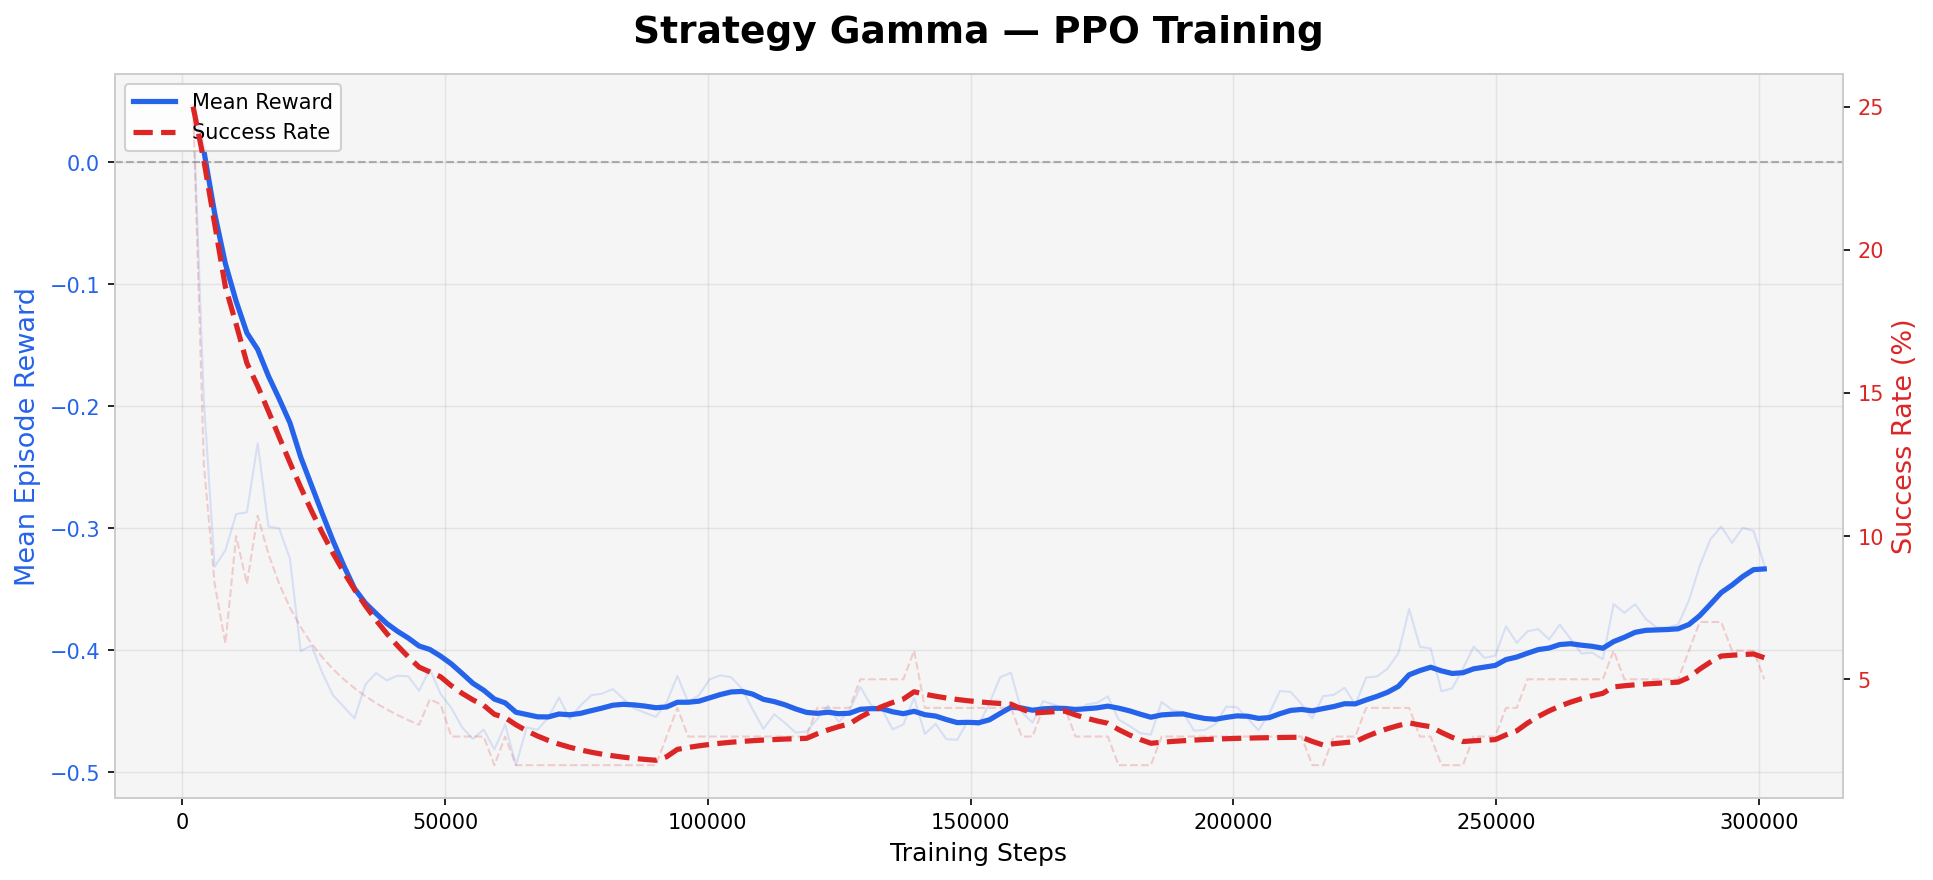

Saved → gamma_training_combined.png


In [29]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
from IPython.display import display, Image as IPImage

LOG_DIR = "./logs/gamma/"

# =========================================================
# Load TensorBoard Scalars
# =========================================================
def load_tb_scalars(log_dir):
    data = defaultdict(list)

    event_files = glob.glob(
        os.path.join(log_dir, "**", "events.out.tfevents.*"),
        recursive=True
    )

    if not event_files:
        print(f"No event files found under {log_dir!r}.")
        return data

    for ef in event_files:
        ea = EventAccumulator(ef, size_guidance={"scalars": 0})
        ea.Reload()

        for tag in ea.Tags().get("scalars", []):
            for event in ea.Scalars(tag):
                data[tag].append((event.step, event.value))

    for tag in data:
        data[tag].sort(key=lambda x: x[0])

    return data


# =========================================================
# Extract metric
# =========================================================
def get(data, tag):
    rows = data.get(tag)

    if not rows:
        return None, None

    steps, vals = zip(*rows)

    return np.array(steps), np.array(vals)


# =========================================================
# Smoothing
# =========================================================
def smooth(values, weight=0.85):
    smoothed = np.zeros_like(values, dtype=float)

    last = values[0]

    for i, v in enumerate(values):
        last = last * weight + v * (1 - weight)
        smoothed[i] = last

    return smoothed


# =========================================================
# Load data
# =========================================================
data = load_tb_scalars(LOG_DIR)

# Metrics
steps_sr, success_rate = get(data, "rollout/success_rate")
steps_rw, reward_mean = get(data, "rollout/ep_rew_mean")

if steps_sr is None or steps_rw is None:
    print("Missing required TensorBoard metrics.")
else:

    # Smooth curves
    success_smooth = smooth(success_rate)
    reward_smooth = smooth(reward_mean)

    # =====================================================
    # Figure
    # =====================================================
    fig, ax1 = plt.subplots(figsize=(13, 6))

    fig.patch.set_facecolor("white")
    ax1.set_facecolor("#f5f5f5")

    # =====================================================
    # LEFT AXIS → Reward
    # =====================================================
    reward_color = "#2563eb"

    # Raw reward
    ax1.plot(
        steps_rw,
        reward_mean,
        color=reward_color,
        linewidth=1,
        alpha=0.15
    )

    # Smoothed reward
    ax1.plot(
        steps_rw,
        reward_smooth,
        color=reward_color,
        linewidth=2.5,
        label="Mean Reward"
    )

    ax1.set_xlabel(
        "Training Steps",
        fontsize=12
    )

    ax1.set_ylabel(
        "Mean Episode Reward",
        color=reward_color,
        fontsize=13
    )

    ax1.tick_params(
        axis="y",
        labelcolor=reward_color
    )

    # Reference line
    ax1.axhline(
        0,
        color="gray",
        linestyle="--",
        linewidth=1,
        alpha=0.6
    )

    # Grid
    ax1.grid(
        True,
        alpha=0.25,
        linewidth=0.7
    )

    # =====================================================
    # RIGHT AXIS → Success Rate
    # =====================================================
    ax2 = ax1.twinx()

    success_color = "#dc2626"

    # Raw success rate
    ax2.plot(
        steps_sr,
        success_rate * 100,
        color=success_color,
        linestyle="--",
        linewidth=1,
        alpha=0.2
    )

    # Smoothed success rate
    ax2.plot(
        steps_sr,
        success_smooth * 100,
        color=success_color,
        linestyle="--",
        linewidth=2.5,
        label="Success Rate"
    )

    ax2.set_ylabel(
        "Success Rate (%)",
        color=success_color,
        fontsize=13
    )

    ax2.tick_params(
        axis="y",
        labelcolor=success_color
    )

    # =====================================================
    # Styling
    # =====================================================
    plt.title(
        "Strategy Gamma — PPO Training",
        fontsize=18,
        fontweight="bold",
        pad=15
    )

    # Light borders
    for spine in ax1.spines.values():
        spine.set_edgecolor("#cccccc")

    for spine in ax2.spines.values():
        spine.set_edgecolor("#cccccc")

    # =====================================================
    # Combined Legend
    # =====================================================
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()

    ax1.legend(
        lines1 + lines2,
        labels1 + labels2,
        loc="upper left",
        framealpha=0.9
    )

    # =====================================================
    # Save
    # =====================================================
    plt.tight_layout()

    plt.savefig(
        "gamma_training_combined.png",
        dpi=150,
        bbox_inches="tight",
        facecolor="white"
    )

    plt.close()

    display(IPImage("gamma_training_combined.png"))

    print("Saved → gamma_training_combined.png")

In [22]:
from IPython.display import FileLink

FileLink(r'checkpoints/gamma/final_gamma_ppo.zip')

/kaggle/working/checkpoints/gamma/final_gamma_ppo.zip